In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict

In [2]:
model = ChatOllama(model="qwen2.5:3b")

In [3]:
class BlogState(TypedDict):
    title: str
    outline: str
    blog: str
    score: float

In [4]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']

    prompt = f'Generate a detailed outline for the log on the title: {title}'

    outline = model.invoke(prompt).content

    state['outline'] = outline

    return state

In [5]:
def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']

    prompt = f'Generate a detailed blog on the title: {title} using the following outline: \n {outline}'

    blog = model.invoke(prompt).content

    state['blog'] = blog

    return state

In [6]:
def evaluate_blog(state: BlogState) -> BlogState:
    outline = state['outline']
    blog = state['blog']

    prompt = f"""
    You are an expert blog evaluator.
    Evaluate the following blog against the provided outline.
    Blog:
    {blog}
    Outline:
    {outline}
    Assign a single overall score between 0.0 and 10.0 based on:
    - Adherence to the outline
    - Depth and completeness of the content
    - Language clarity, grammar, and readability
    - Logical organization and flow
    - Relevance and coherence
    Output only the numeric score as a floating-point number (e.g., 8.7). Do not include any explanation, text, or additional formatting.
    """

    score = model.invoke(prompt).content

    state['score'] = score

    return state

In [7]:
graph = StateGraph(BlogState)

graph.add_node('CreateOutline', create_outline)
graph.add_node('CreateBlog', create_blog)
graph.add_node('EvaluateBlog', evaluate_blog)

graph.add_edge(START, 'CreateOutline')
graph.add_edge('CreateOutline', 'CreateBlog')
graph.add_edge('CreateBlog', 'EvaluateBlog')
graph.add_edge('EvaluateBlog', END)

workflow = graph.compile()

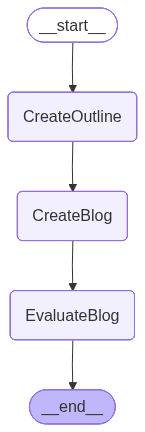

In [8]:
workflow

In [9]:
initial_state = {'title': 'The Stationery Shop of Tehran'}

final_answer = workflow.invoke(initial_state)

In [10]:
final_answer

{'title': 'The Stationery Shop of Tehran',
 'outline': 'Certainly! Below is a detailed outline for a log titled "The Stationery Shop of Tehran," which could be used as a guide to document the opening, operations, and experiences at this fictional stationery shop in Tehran. This outline will include sections like background information, daily operations, staff profiles, customer interactions, product offerings, and more.\n\n### Title: The Stationery Shop of Tehran\n#### 1. Background Information:\n   - **Location:** A quaint neighborhood located between the hustle of busy streets and the serene ambiance of a tranquil park in Tehran.\n   - **Founder:** An artist named Ali, who was inspired by his grandmother’s crafty nature while growing up.\n   - **Concept:** A stationery shop that caters to both local artisans and international customers looking for unique items for their personal collections or art projects.\n   - **Mission Statement:** To preserve traditional craftsmanship through ou

In [11]:
final_answer['title']

'The Stationery Shop of Tehran'

In [12]:
print(final_answer['outline'])

Certainly! Below is a detailed outline for a log titled "The Stationery Shop of Tehran," which could be used as a guide to document the opening, operations, and experiences at this fictional stationery shop in Tehran. This outline will include sections like background information, daily operations, staff profiles, customer interactions, product offerings, and more.

### Title: The Stationery Shop of Tehran
#### 1. Background Information:
   - **Location:** A quaint neighborhood located between the hustle of busy streets and the serene ambiance of a tranquil park in Tehran.
   - **Founder:** An artist named Ali, who was inspired by his grandmother’s crafty nature while growing up.
   - **Concept:** A stationery shop that caters to both local artisans and international customers looking for unique items for their personal collections or art projects.
   - **Mission Statement:** To preserve traditional craftsmanship through our offerings and support local artisans in Tehran.

#### 2. Dail

In [13]:
print(final_answer['blog'])

### The Stationery Shop of Tehran

#### 1. Background Information:
- **Location:** A quaint neighborhood located between the hustle of busy streets and the serene ambiance of a tranquil park in Tehran.
- **Founder:** An artist named Ali, who was inspired by his grandmother’s crafty nature while growing up.
- **Concept:** A stationery shop that caters to both local artisans and international customers looking for unique items for their personal collections or art projects.
- **Mission Statement:** To preserve traditional craftsmanship through our offerings and support local artisans in Tehran.

#### 2. Daily Operations:
- **Opening Hours:**
  - Morning: 10 AM – 1 PM
  - Afternoon: 3 PM – 6 PM
- **Inventory Management:**
  - Regularly updating stock based on customer feedback and seasonal trends.
  - Maintaining a system to track the quality of each item, ensuring authenticity.
- **Product Sourcing:**
  - Partnering with local artisans who specialize in traditional Persian crafts like pa

In [14]:
print(final_answer['score'])

9.2
